In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_pour_ml.csv")

In [5]:
df.columns

Index(['year', 'country_name', 'life_evaluation_3_year_average',
       'explained_by_log_gdp_per_capita', 'explained_by_social_support',
       'explained_by_healthy_life_expectancy',
       'explained_by_freedom_to_make_life_choices', 'explained_by_generosity',
       'explained_by_perceptions_of_corruption', 'key_iso3_year',
       'inflation_cpi', 'gdp_current_usd', 'gdp_per_capita_current_usd',
       'unemployment_rate_', 'inflation_gdp_deflator', 'gdp_growth_annual',
       'current_account_balance_gdp', 'government_expense_of_gdp',
       'government_revenue_of_gdp', 'tax_revenue_of_gdp',
       'gross_national_income_usd', 'country_code'],
      dtype='str')

Definition de x et y

In [63]:
y = df["life_evaluation_3_year_average"]

X = df.drop(columns=[
    "life_evaluation_3_year_average",
    "country_name", "country_code", "key_iso3_year", "year",
    "explained_by_log_gdp_per_capita",
    "explained_by_social_support",
    "explained_by_healthy_life_expectancy",
    "explained_by_freedom_to_make_life_choices",
    "explained_by_generosity",
    "explained_by_perceptions_of_corruption",
    "gdp_current_usd",
    "gross_national_income_usd"
])

In [64]:
cols_id = ["country_name", "country_code", "key_iso3_year", "year"]

cols_explained = [
    "explained_by_log_gdp_per_capita",
    "explained_by_social_support",
    "explained_by_healthy_life_expectancy",
    "explained_by_freedom_to_make_life_choices",
    "explained_by_generosity",
    "explained_by_perceptions_of_corruption"
]

cols_wealth = [
    "gdp_current_usd",
    "gdp_per_capita_current_usd"
]

# Dataset propre pour le VIF (on garde les variables économiques)
X_full = df.drop(columns=cols_id + cols_explained + ["life_evaluation_3_year_average"])


In [65]:
X_vif = df.drop(columns=cols_id + cols_explained)

imputation

In [66]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="median")
X_imputed = imp.fit_transform(X_full)

# On recrée un DataFrame propre
X_clean = pd.DataFrame(X_imputed, columns=X_full.columns)

Standarisation des features

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["feature"] = X_clean.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

vif_data.sort_values("VIF", ascending=False)

,feature,VIF
1,gdp_current_usd,5422.484667
10,gross_national_income_usd,5413.866900
8,government_revenue_of_gdp,6.149466
7,government_expense_of_gdp,5.024650
9,tax_revenue_of_gdp,2.483929
2,gdp_per_capita_current_usd,1.600489
6,current_account_balance_gdp,1.333089
0,inflation_cpi,1.293018
4,inflation_gdp_deflator,1.284391
3,unemployment_rate_,1.154484


In [ ]:
!pip install statsmodels

In [68]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# On part de X_full ou X_macro selon ton choix
X = X_full.copy()

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=1e-4)  # très faible
X_var = selector.fit_transform(X_clean)

# Récupérer les colonnes conservées
cols_kept = X_clean.columns[selector.get_support()]
X_var = pd.DataFrame(X_var, columns=cols_kept)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var)

# Calcul du VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_var.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

vif_data.sort_values("VIF", ascending=False)

,feature,VIF
1,gdp_current_usd,5422.484667
10,gross_national_income_usd,5413.866900
8,government_revenue_of_gdp,6.149466
7,government_expense_of_gdp,5.024650
9,tax_revenue_of_gdp,2.483929
2,gdp_per_capita_current_usd,1.600489
6,current_account_balance_gdp,1.333089
0,inflation_cpi,1.293018
4,inflation_gdp_deflator,1.284391
3,unemployment_rate_,1.154484


In [69]:
cols_to_remove = [
    "gdp_current_usd",
    "gross_national_income_usd"
]

X_vif2 = X_vif.drop(columns=cols_to_remove)

# Imputation
imp = SimpleImputer(strategy="median")
X_imputed2 = imp.fit_transform(X_vif2)
X_clean2 = pd.DataFrame(X_imputed2, columns=X_vif2.columns)

# Variance threshold
selector = VarianceThreshold(threshold=1e-4)
X_var2 = selector.fit_transform(X_clean2)
cols_kept2 = X_clean2.columns[selector.get_support()]
X_var2 = pd.DataFrame(X_var2, columns=cols_kept2)

# Standardisation
scaler = StandardScaler()
X_scaled2 = scaler.fit_transform(X_var2)

# VIF
vif_data2 = pd.DataFrame()
vif_data2["feature"] = X_var2.columns
vif_data2["VIF"] = [variance_inflation_factor(X_scaled2, i) for i in range(X_scaled2.shape[1])]

vif_data2.sort_values("VIF", ascending=False)

,feature,VIF
8,government_revenue_of_gdp,5.844278
7,government_expense_of_gdp,4.768647
9,tax_revenue_of_gdp,2.436373
2,gdp_per_capita_current_usd,2.088836
0,life_evaluation_3_year_average,2.078040
6,current_account_balance_gdp,1.342286
1,inflation_cpi,1.315464
4,inflation_gdp_deflator,1.287273
3,unemployment_rate_,1.203578
5,gdp_growth_annual,1.072235


In [70]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline standardisation + LassoCV
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=0))
])

lasso.fit(X_var2, y)

# Récupérer les coefficients
coef = pd.Series(lasso.named_steps["lasso"].coef_, index=X_var2.columns)

# Variables sélectionnées (coef ≠ 0)
selected_features = coef[coef != 0].index.tolist()

selected_features

['life_evaluation_3_year_average']

In [71]:
from sklearn.linear_model import RidgeCV

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=[0.1, 1.0, 10.0]))
])

ridge.fit(X_var2, y)

coef_ridge = pd.Series(ridge.named_steps["ridge"].coef_, index=X_var2.columns)
coef_ridge.sort_values(ascending=False)

life_evaluation_3_year_average    1.125655
gdp_per_capita_current_usd        0.000066
government_expense_of_gdp         0.000024
current_account_balance_gdp       0.000010
government_revenue_of_gdp         0.000002
gdp_growth_annual                -0.000001
tax_revenue_of_gdp               -0.000004
inflation_gdp_deflator           -0.000005
inflation_cpi                    -0.000013
unemployment_rate_               -0.000019
dtype: float64

Split tain et test

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

Regression Linéaire 

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Evaluation

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

# --- TEST ---
y_pred_test = model.predict(x_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5
r2_test = r2_score(y_test, y_pred_test)

print("TEST RMSE:", rmse_test)
print("TEST R²:", r2_test)

# --- TRAIN ---
y_pred_train = model.predict(x_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
r2_train = r2_score(y_train, y_pred_train)

print("TRAIN RMSE:", rmse_train)
print("TRAIN R²:", r2_train)

TEST RMSE: 0.6631468482401939
TEST R²: 0.6513099492942245
TRAIN RMSE: 0.705785449766348
TRAIN R²: 0.6073897083658728


Installation de XGBoost

In [12]:
!pip install xgboost


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Création du modèle

In [13]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

Entraîner le modèle

In [14]:
model_xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Prédiction

In [15]:
y_pred_xgb = model_xgb.predict(x_test)

Evaluation

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 0.37440791135988855
XGBoost R²: 0.8888498201378086


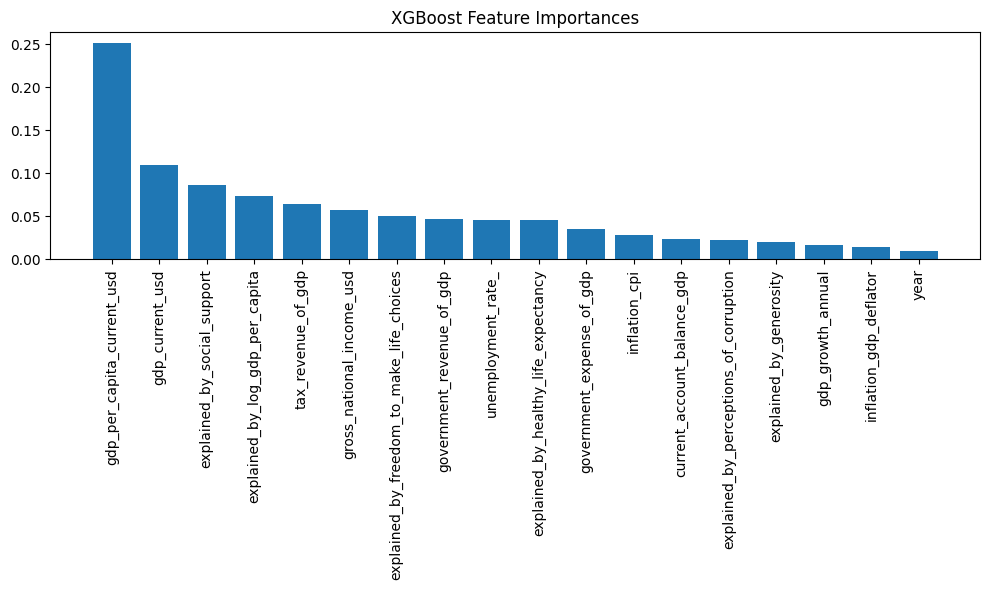

In [17]:
import matplotlib.pyplot as plt
import numpy as np

importances = model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
features = x.columns

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

Refaire le modèle sans les varaibles explained_by...

In [18]:
cols_to_remove = [col for col in x.columns if col.startswith("explained_by_")]
x_wb = x.drop(columns=cols_to_remove)

Refaire l'imputation

In [19]:
x_imputed = imputer.fit_transform(x_wb)
x_scaled = scaler.fit_transform(x_imputed)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

Entraîner à nouveau le XGBoost

In [20]:
model_xgb.fit(x_train, y_train)
y_pred_xgb = model_xgb.predict(x_test)

Réévaluer le modèle

In [21]:
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 0.478780904829648
XGBoost R²: 0.8182418983038934


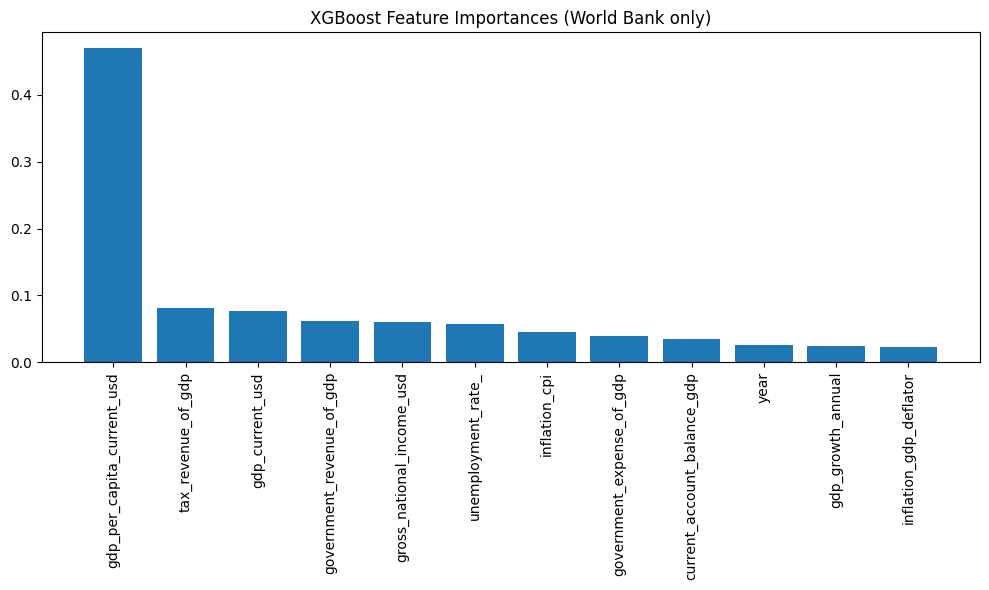

In [22]:
importances = model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
features = x_wb.columns

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.title("XGBoost Feature Importances (World Bank only)")
plt.tight_layout()
plt.show()

Dans quelle mesure les variables de la World Bank expliquent le bonheur, indépendamment des variables du World Happiness Report ?

Retirer les variables richesse

In [23]:
wealth_vars = [
    "gdp_per_capita_current_usd",
    "gdp_current_usd",
    "gross_national_income_usd"
]

x_no_wealth = x_wb.drop(columns=wealth_vars)

Refaire pipeline

### Projection des variables macroéconomiques pour 2025–2030

Nous générons ici les valeurs futures de toutes les variables macroéconomiques nécessaires au modèle final de bonheur. Le principe consiste à partir de la dernière année observée (2024) et à projeter chaque année de manière récursive jusqu’en 2030.

1. **Point de départ :**  
   Nous récupérons la dernière ligne disponible dans les données (année 2024), qui sert d’état initial pour les projections.

2. **Projection du PIB par habitant :**  
   Le PIB par habitant est projeté en premier, car il constitue une variable centrale et dépendante de l’ensemble des autres indicateurs macro.  
   Nous utilisons le modèle `model_gdp` pour prédire sa valeur future à partir des variables de l’année précédente.

3. **Projection des autres variables macro :**  
   Pour chaque variable de `macro_targets`, nous utilisons le modèle XGBoost correspondant (stocké dans `macro_models`).  
   Chaque modèle prend en entrée toutes les autres variables macro de l’année précédente, ce qui garantit une cohérence structurelle entre les projections.

4. **Construction de la série future :**  
   À chaque itération :
   - nous créons une nouvelle ligne contenant l’année projetée et toutes les variables macro prédites,
   - nous ajoutons cette ligne à la liste `df_future_macro`,
   - nous utilisons cette nouvelle ligne comme base pour prédire l’année suivante.

Ce processus récursif permet de générer un scénario macroéconomique complet et cohérent pour les années 2025 à 2030, qui servira ensuite d’entrée au modèle final de bonheur.

In [24]:
x_imputed = imputer.fit_transform(x_no_wealth)
x_scaled = scaler.fit_transform(x_imputed)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

Entraîner à nouveau

In [25]:
model_xgb.fit(x_train, y_train)
y_pred_xgb = model_xgb.predict(x_test)

Evaluer à nouveau

In [26]:
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 0.667768928291308
XGBoost R²: 0.6464323269448511


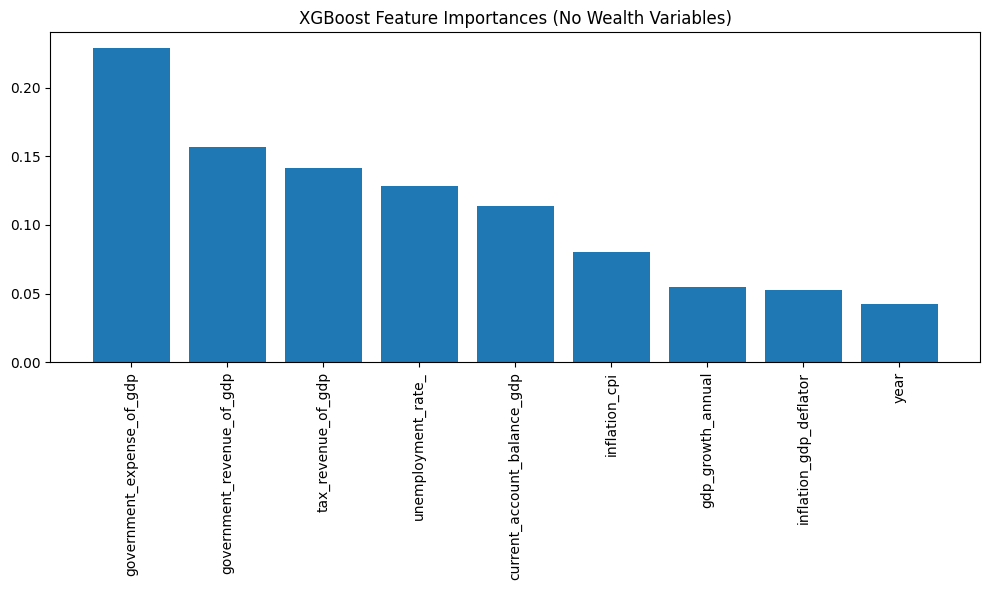

In [27]:
importances = model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
features = x_no_wealth.columns

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.title("XGBoost Feature Importances (No Wealth Variables)")
plt.tight_layout()
plt.show()

L’inflation a un effet fortement négatif sur le bonheur, particulièrement lorsqu’elle dépasse 10 %. L’interaction avec le chômage montre que l’impact de l’inflation est amplifié dans les pays où le chômage est élevé, ce qui reflète un phénomène de type “stagflation”. À l’inverse, les pays à faible chômage amortissent mieux l’effet négatif de l’inflation. Ces résultats soulignent que la stabilité des prix est un déterminant majeur du bien‑être, surtout lorsque le marché du travail est fragile.

In [34]:
year_target = 2023

idx = df.index[(df['country_name'] == "Costa Rica") & (df['year'] == year_target)][0]

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    df_no_wealth.loc[idx]
)

NameError: name 'df_no_wealth' is not defined

En 2023, le Costa Rica présente un profil macroéconomique globalement favorable. L’inflation très faible, des recettes publiques élevées et un chômage modéré constituent les principaux facteurs qui tirent le score de bonheur vers le haut. Malgré des dépenses publiques importantes, le modèle prédit un niveau de bonheur nettement supérieur à la moyenne mondiale, reflétant la stabilité institutionnelle et la résilience économique du pays.

In [ ]:
import shap
shap.initjs()

# --- Costa Rica ---
idx_cr = df.index[(df['country_name'] == "Costa Rica") & (df['year'] == 2023)][0]

display(shap.force_plot(
    explainer.expected_value,
    shap_values[idx_cr],
    df_no_wealth.loc[idx_cr]
))

# --- Finlande ---
idx_fi = df.index[(df['country_name'] == "Finland") & (df['year'] == 2023)][0]

display(shap.force_plot(
    explainer.expected_value,
    shap_values[idx_fi],
    df_no_wealth.loc[idx_fi]
))

In [ ]:
df.columns

Index(['year', 'country_name', 'life_evaluation_3_year_average',
       'explained_by_log_gdp_per_capita', 'explained_by_social_support',
       'explained_by_healthy_life_expectancy',
       'explained_by_freedom_to_make_life_choices', 'explained_by_generosity',
       'explained_by_perceptions_of_corruption', 'key_iso3_year',
       'inflation_cpi', 'gdp_current_usd', 'gdp_per_capita_current_usd',
       'unemployment_rate_', 'inflation_gdp_deflator', 'gdp_growth_annual',
       'current_account_balance_gdp', 'government_expense_of_gdp',
       'government_revenue_of_gdp', 'tax_revenue_of_gdp',
       'gross_national_income_usd', 'country_code'],
      dtype='str')

In [2]:
import pandas as pd
df = pd.read_csv("../data/processed/final_clean.csv")
print(df.columns)

Index(['year', 'country_name', 'life_evaluation_3_year_average',
       'lower_whisker', 'upper_whisker', 'explained_by_log_gdp_per_capita',
       'explained_by_social_support', 'explained_by_healthy_life_expectancy',
       'explained_by_freedom_to_make_life_choices', 'explained_by_generosity',
       'explained_by_perceptions_of_corruption', 'dystopia_residual',
       'key_iso3_year', 'inflation_cpi', 'gdp_current_usd',
       'gdp_per_capita_current_usd', 'unemployment_rate_',
       'interest_rate_real', 'inflation_gdp_deflator', 'gdp_growth_annual',
       'current_account_balance_gdp', 'government_expense_of_gdp',
       'government_revenue_of_gdp', 'tax_revenue_of_gdp',
       'gross_national_income_usd', 'public_debt_of_gdp', 'country_code'],
      dtype='str')
